# Raw (before-WZA) mirror Manhattans — SNP vs SV, LFMM, clq0.9 TILING, all 20 axes

Successor to `raw_manhattan_snp_vs_sv_lfmm.ipynb`, which used the **strict** clq0.9
partition (interval containment) — that partition drops 39.7% of SNP / 49.3% of SV /
40.7% of non-SNP records that fall in inter-block gaps. This version uses the
**tiling** reblocking (`reblock_blockdef.py --how tiling`, HapFM's gap-free rule): every
record keeps a block, same LD boundaries, **0% dropped**.

Per-record `wza_in_clq09_tile` p-values (the input WZA aggregates, not the block-level
output) — one figure per climate axis (bio1-19 + pc1), LFMM only. SNP up, sv down.
Dashed = per-class Bonferroni (0.05/n records). Vertical dotted line + gene label = a
tiling block whose lead sv record is Bonferroni-sig while its lead SNP record in the
same block is not ("new" peak, first-pass — not yet checked for SNP-tagging).

In [1]:
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import lib
GEA = lib.GEA
WZAIN = f"{GEA}/phase1_replication/results/multiaxis/wza_in_clq09_tile"
AXES = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
MODEL = "lfmm"
CLS = "sv"
CHROM_LEN = {"Chr1":30427671,"Chr2":19698289,"Chr3":23459830,"Chr4":18585056,"Chr5":26975502}
CH = list(CHROM_LEN); OFF = {}; _a = 0
for _c in CH: OFF[_c] = _a; _a += CHROM_LEN[_c]
plt.rcParams.update({"figure.dpi":110})
SNP_DARK, SNP_LIGHT = "#495057", "#ADB5BD"
CLS_DARK  = "#c0392b" if CLS == "sv" else "#1B5E20"
CLS_LIGHT = "#e8a58c" if CLS == "sv" else "#66BB6A"

def block_spans_tiling(r2=0.9):
    """Tiling block spans: each block absorbs the preceding gap (matches reblock_blockdef.py)."""
    tag=f"clq{r2}"; rows=[]
    for ci in range(1,6):
        ch = f"Chr{ci}"
        g=pd.read_csv(f"{lib.CLQ_BLOCKS_DIR}/chr{ci}_{tag}_blocks_{tag}.tsv",sep="\t").sort_values("start_pos").reset_index(drop=True)
        ends = g.end_pos.to_numpy(np.int64)
        for i in range(len(g)):
            lo = 1 if i == 0 else int(ends[i-1]) + 1
            hi = int(ends[i]) if i < len(g)-1 else 10**9
            rows.append((f"{ch}_{i}", ch, lo, hi))
    return pd.DataFrame(rows,columns=["block","chrom","start","end"]).set_index("block")
SPANS=block_spans_tiling(); GENES=lib.load_genes()
def genes_on(block):
    if block not in SPANS.index: return []
    s=SPANS.loc[block]; gc=GENES[(GENES.chrom==s.chrom)&(GENES.end>=s.start)&(GENES.start<=s.end)]
    return list(gc.gene)
print("loaded:", len(SPANS), "tiling blocks,", len(GENES), "genes ; class =", CLS)

loaded: 58376 tiling blocks, 27206 genes ; class = sv


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


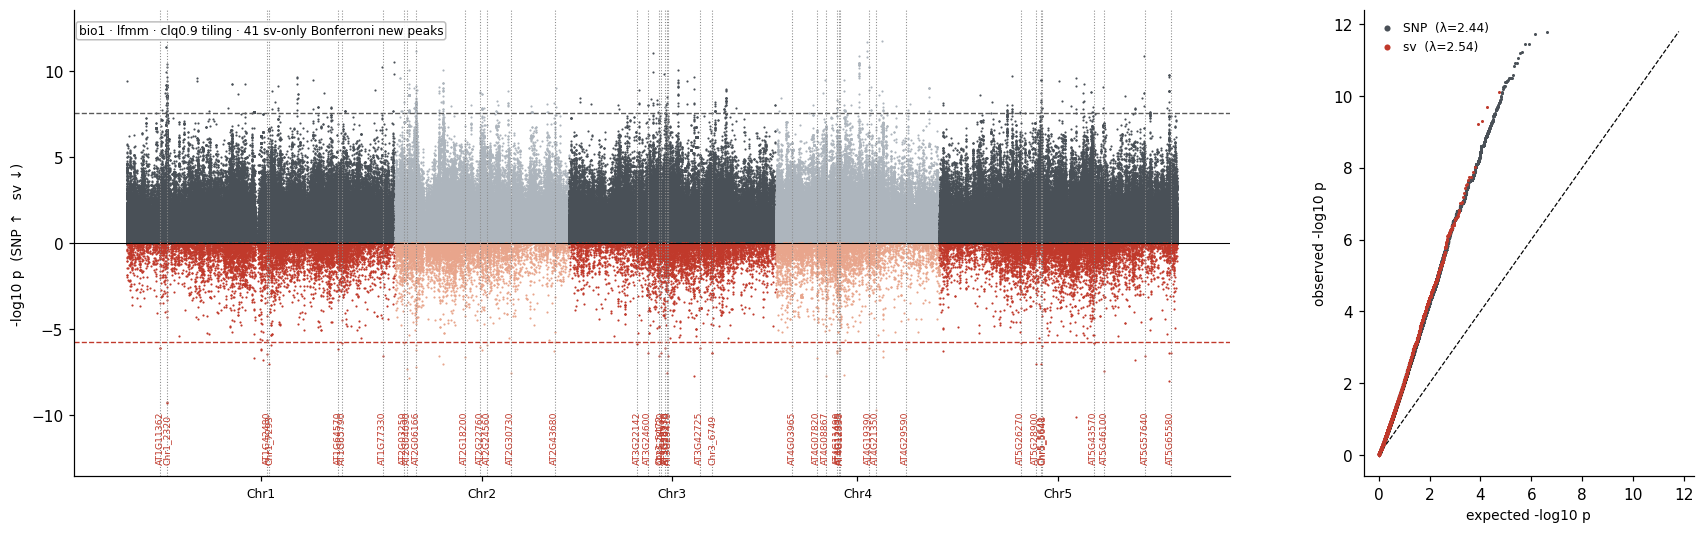

bio1: 41 sv-only Bonferroni new peaks (gene-bearing: 35)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,9.679483,4.549587
456,Chr1_2320,Chr1,4583448,,9.307433,6.384279
2855,Chr4_1966,Chr4,5702291,AT4G08867;AT4G08868;AT4G08869;AT4G08870;AT4G08...,7.738623,7.079312
2312,Chr3_5969,Chr3,11139430,AT3G29170,7.539467,5.700082
1760,Chr2_5291,Chr2,13127635,AT2G30730;AT2G30740,7.528744,2.068286
4464,Chr5_9247,Chr5,18697015,AT5G46100;AT5G46110,7.435030,4.053623
1921,Chr2_825,Chr2,1364859,AT2G04090;AT2G04100,7.292547,7.314099
4001,Chr5_5641,Chr5,11481464,,7.055737,5.382674
890,Chr1_7293,Chr1,16186470,,7.020630,6.661156
3985,Chr5_5520,Chr5,10926456,AT5G28900;AT5G28910,7.016282,3.871117


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


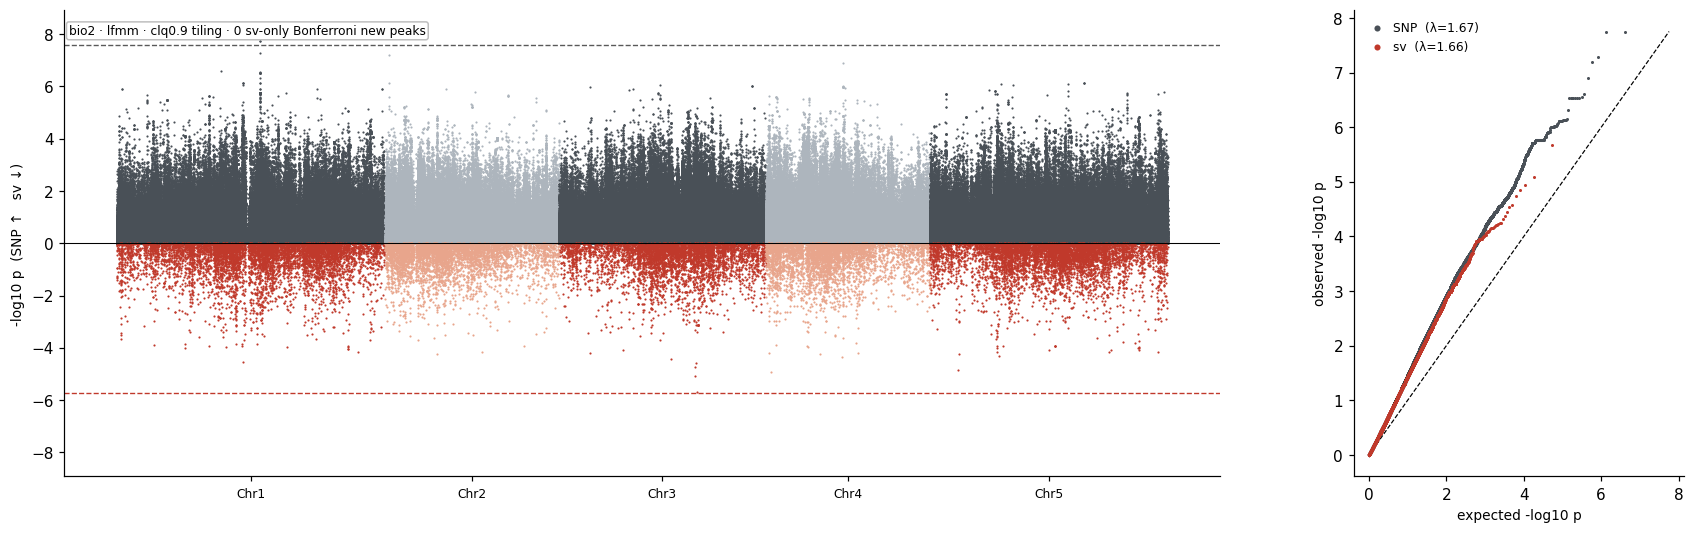

bio2: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


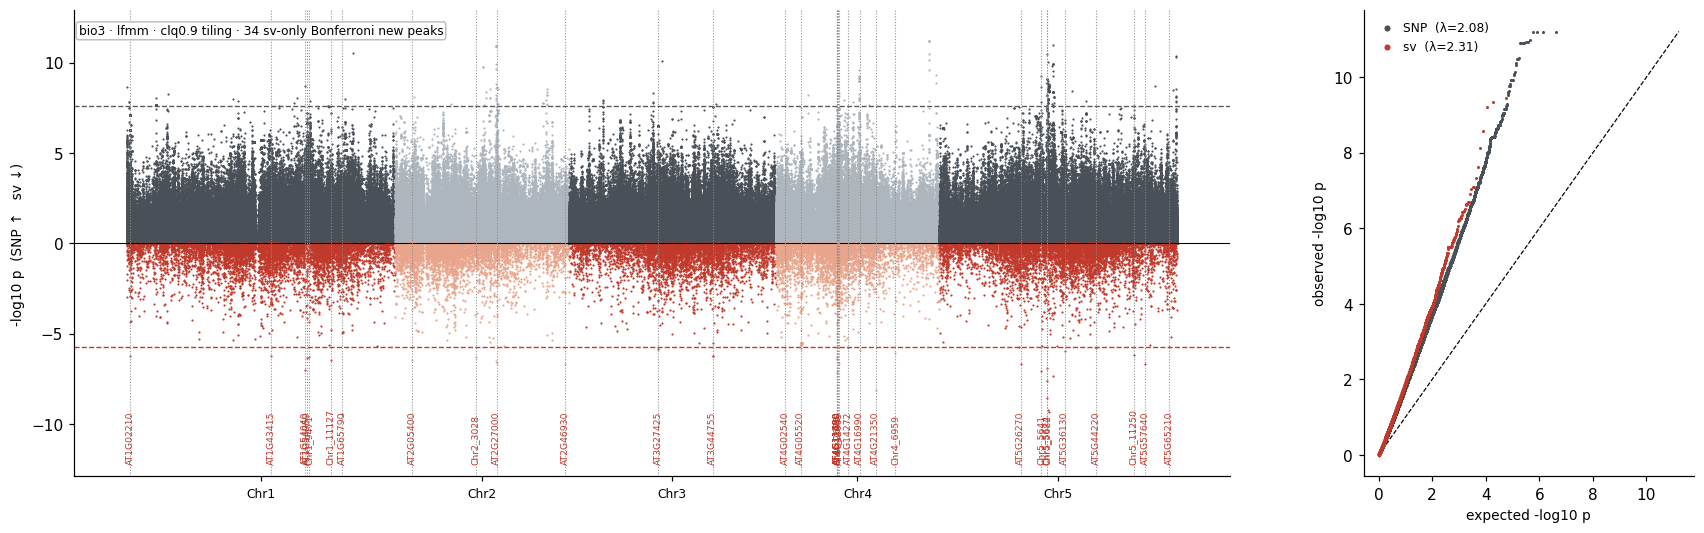

bio3: 34 sv-only Bonferroni new peaks (gene-bearing: 25)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
194,Chr1_12318,Chr1,24470448,AT1G65790;AT1G65800,9.442863,3.906755
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,8.114537,3.838380
4012,Chr5_5674,Chr5,12151493,,7.620070,6.797293
2978,Chr4_2749,Chr4,7011705,AT4G11600;AT4G11610,7.104377,7.398026
4001,Chr5_5641,Chr5,11481464,,7.089872,4.981621
1121,Chr1_9297,Chr1,20268185,AT1G54040,7.035176,3.064242
4013,Chr5_5682,Chr5,12191717,,6.918843,6.650026
3567,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,6.692376,4.841912
3894,Chr5_4928,Chr5,9207553,AT5G26270,6.688590,2.603577
1925,Chr2_8310,Chr2,19309838,AT2G46930,6.654863,3.203477


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


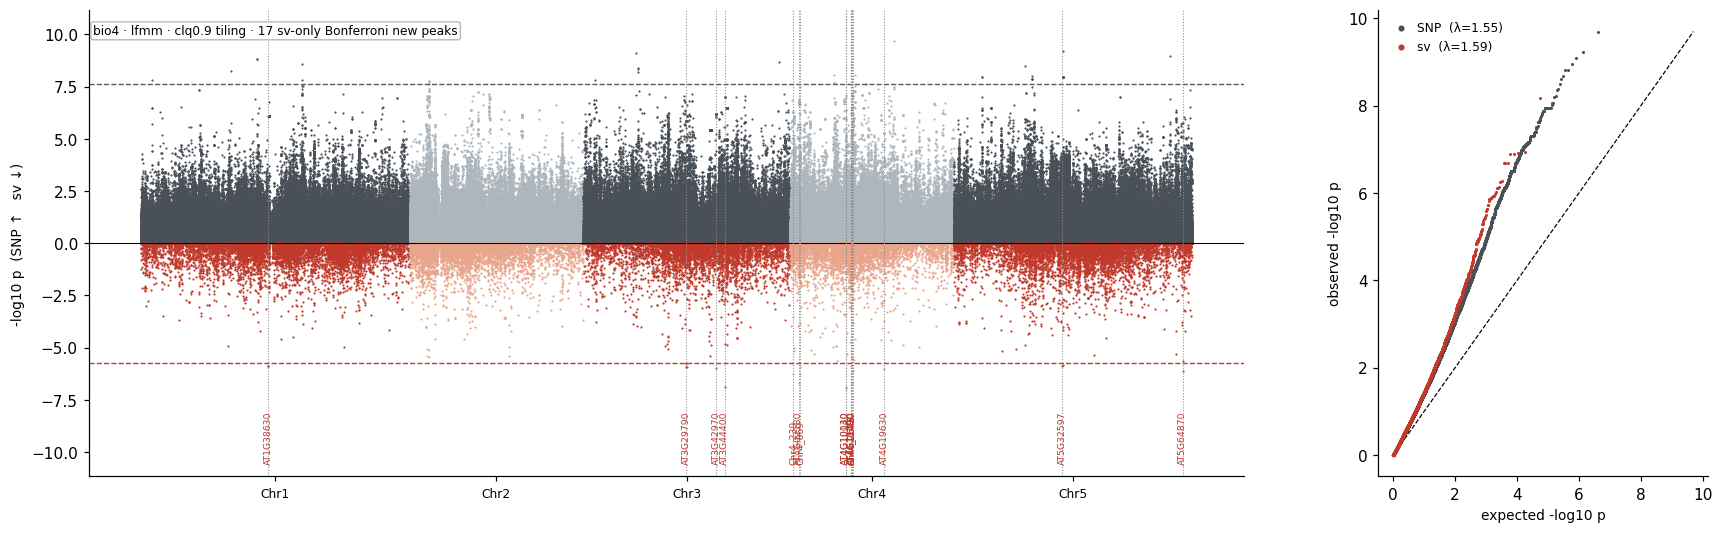

bio4: 17 sv-only Bonferroni new peaks (gene-bearing: 13)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2968,Chr4_2675,Chr4,6934090,,8.182409,2.276622
2898,Chr4_2251,Chr4,6322337,AT4G10130;AT4G10140,6.931569,7.102462
2893,Chr4_2229,Chr4,6280048,AT4G10040;AT4G10050,6.917630,4.952033
2452,Chr3_6648,Chr3,16050773,AT3G44400;AT3G44428;AT3G44430;AT3G44440,6.884246,6.996577
2972,Chr4_2720,Chr4,6978538,AT4G11490,6.690158,2.207778
2973,Chr4_2725,Chr4,6982683,AT4G11490;AT4G11510;AT4G11521;AT4G11530,6.690158,7.113944
3331,Chr4_737,Chr4,963452,AT4G02180;AT4G02190,6.689222,6.901360
2919,Chr4_239,Chr4,314269,,6.271687,6.263378
3391,Chr4_869,Chr4,1143262,,6.257241,6.652391
3624,Chr5_13462,Chr5,25931490,AT5G64870;AT5G64880,6.130969,5.774118


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


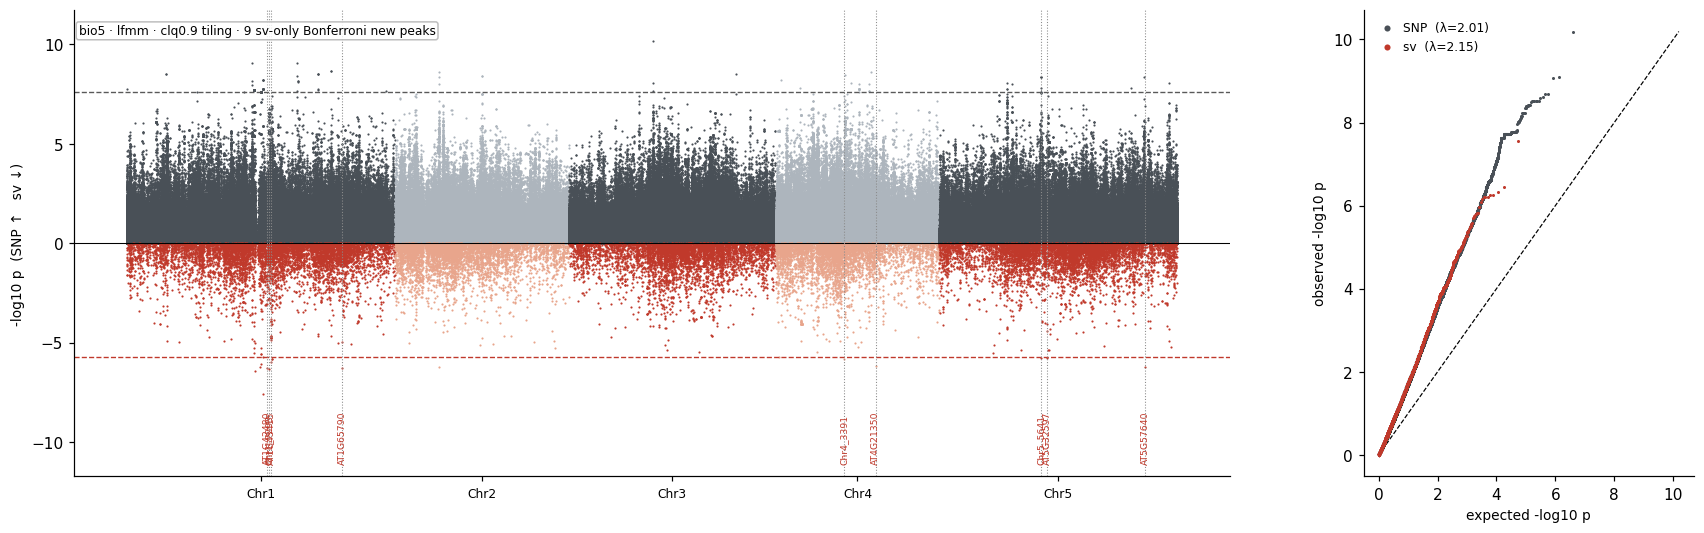

bio5: 9 sv-only Bonferroni new peaks (gene-bearing: 6)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
890,Chr1_7293,Chr1,16186470,,6.331815,6.567455
878,Chr1_7247,Chr1,15961035,AT1G42480;AT1G42525,6.255063,5.892693
194,Chr1_12318,Chr1,24470448,AT1G65790;AT1G65800,6.251979,3.887938
3567,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,6.218091,4.372033
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,6.155746,3.945693
898,Chr1_7339,Chr1,16404245,AT1G43415;AT1G43560;AT1G43580;AT1G43600;AT1G43...,5.964763,6.930618
3056,Chr4_3391,Chr4,7812731,,5.800210,7.419112
4017,Chr5_5688,Chr5,12249307,AT5G32597,5.784936,5.607410
4001,Chr5_5641,Chr5,11481464,,5.754009,5.007295


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


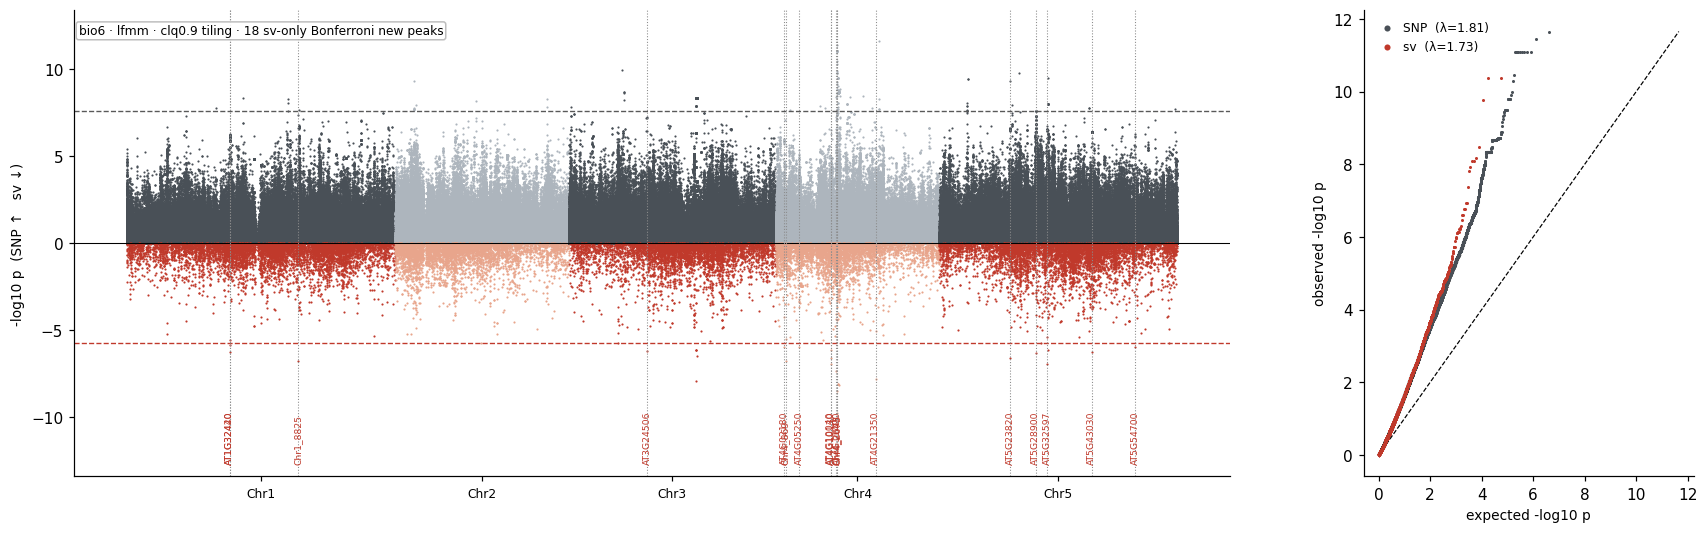

bio6: 18 sv-only Bonferroni new peaks (gene-bearing: 14)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2972,Chr4_2720,Chr4,6978538,AT4G11490,10.377719,2.562796
2968,Chr4_2675,Chr4,6934090,,9.756523,3.296069
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,7.825166,6.583055
2960,Chr4_2643,Chr4,6890596,,7.360544,2.469746
4017,Chr5_5688,Chr5,12251214,AT5G32597,6.947458,6.000619
2898,Chr4_2251,Chr4,6321638,AT4G10130;AT4G10140,6.938251,6.489163
3391,Chr4_869,Chr4,1143262,,6.772831,5.601192
1082,Chr1_8825,Chr1,19426362,,6.765350,7.364293
3812,Chr5_4137,Chr5,8036567,AT5G23820;AT5G23830;AT5G23840,6.604513,6.637027
3985,Chr5_5520,Chr5,10926456,AT5G28900;AT5G28910,6.305191,3.701323


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


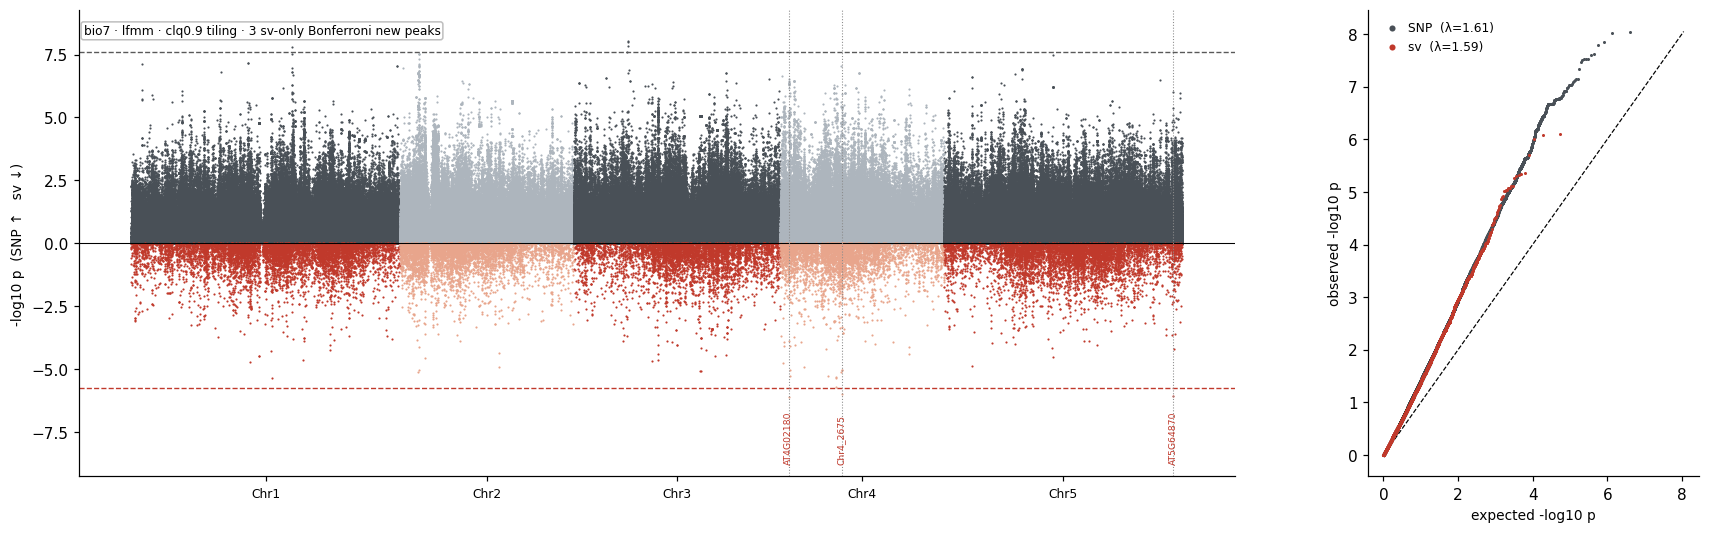

bio7: 3 sv-only Bonferroni new peaks (gene-bearing: 2)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
3331,Chr4_737,Chr4,963452,AT4G02180;AT4G02190,6.105543,6.528019
3624,Chr5_13462,Chr5,25931490,AT5G64870;AT5G64880,6.081865,6.003115
2968,Chr4_2675,Chr4,6934090,,6.007167,1.689769


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


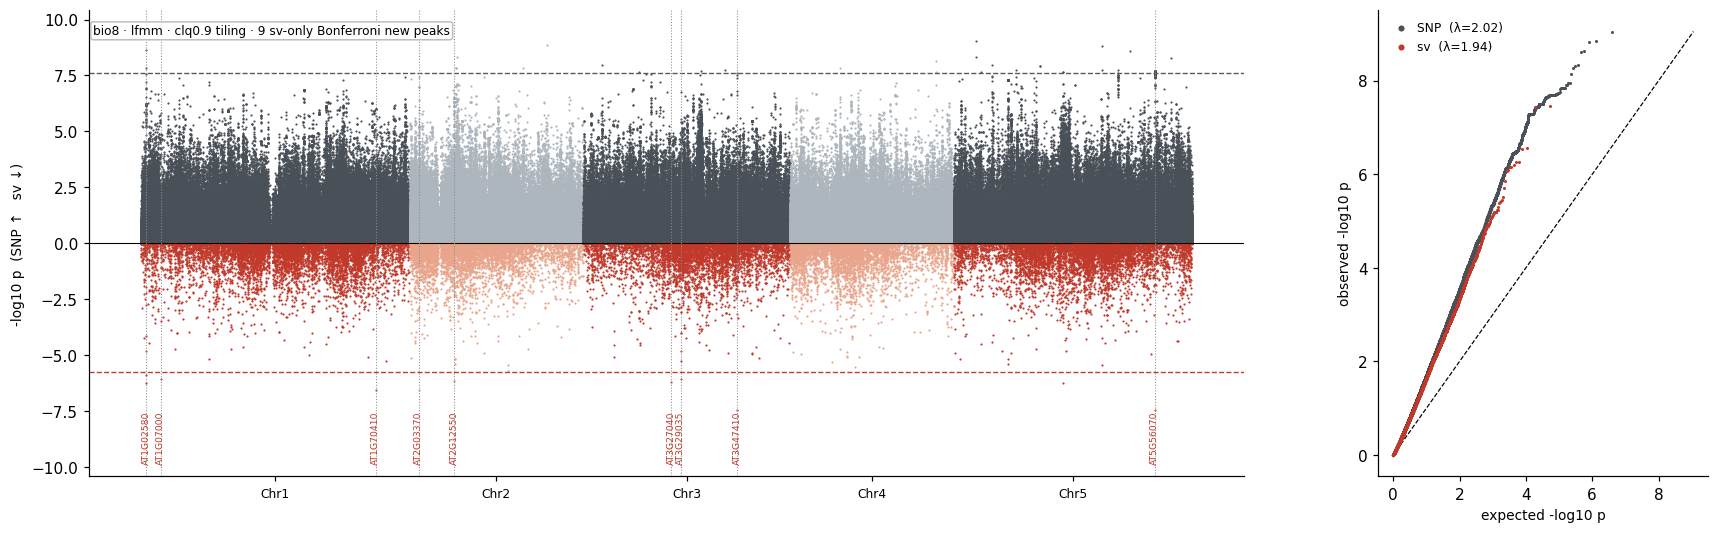

bio8: 9 sv-only Bonferroni new peaks (gene-bearing: 9)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2536,Chr3_7513,Chr3,17476013,AT3G47410;AT3G47420,7.456582,2.463013
3550,Chr5_11696,Chr5,22757963,AT5G56070,7.449212,3.853924
1838,Chr2_677,Chr2,1027540,AT2G03370,6.554114,7.438224
312,Chr1_13784,Chr1,26583632,AT1G70410;AT1G70420;AT1G70430;AT1G70440,6.548415,2.644732
506,Chr1_330,Chr1,549566,AT1G02580,6.254601,7.216277
2233,Chr3_5321,Chr3,9982702,AT3G27040;AT3G27050,6.197468,1.731596
1317,Chr2_1440,Chr2,5077103,AT2G12550,6.148172,7.045663
2306,Chr3_5945,Chr3,11041140,AT3G29035;AT3G29040;AT3G29050;AT3G29060,6.084447,5.422670
63,Chr1_1069,Chr1,2213049,AT1G07000;AT1G07010;AT1G07020;AT1G07025;AT1G07...,6.075683,4.712115


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


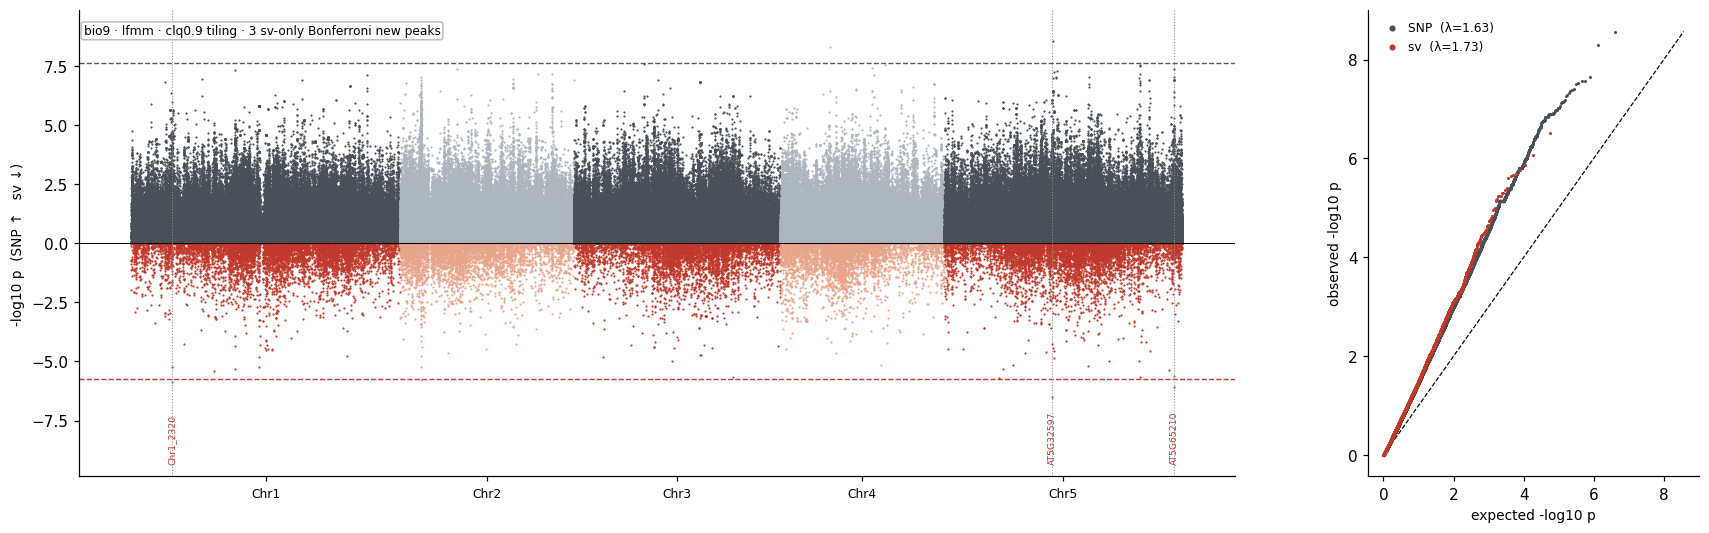

bio9: 3 sv-only Bonferroni new peaks (gene-bearing: 2)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
4017,Chr5_5688,Chr5,12249307,AT5G32597,6.511908,6.080774
3627,Chr5_13532,Chr5,26073562,AT5G65210;AT5G65220;AT5G65230,6.067784,7.366416
456,Chr1_2320,Chr1,4584348,,5.872540,4.532786


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


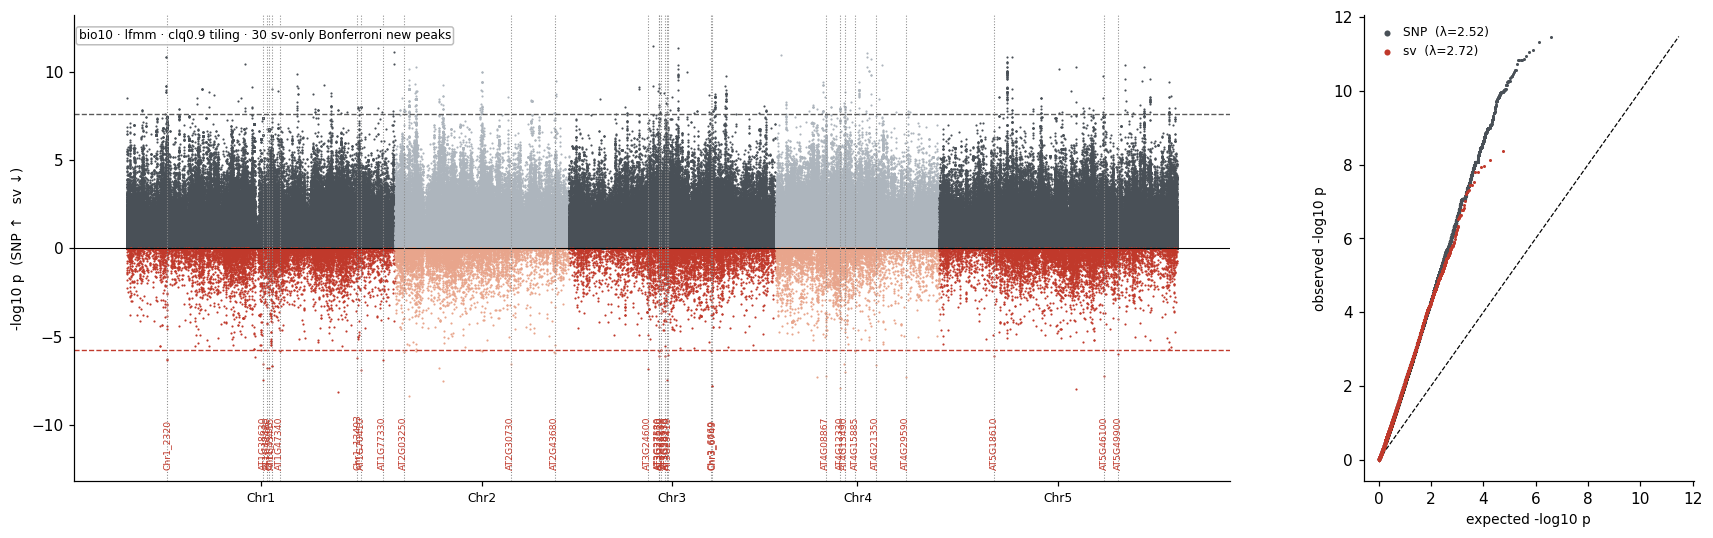

bio10: 30 sv-only Bonferroni new peaks (gene-bearing: 25)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
3015,Chr4_3017,Chr4,7319259,AT4G12330;AT4G12334;AT4G12340,7.930239,4.479661
2466,Chr3_6749,Chr3,16279305,,7.791567,6.968803
867,Chr1_7218,Chr1,15478870,AT1G38630;AT1G38790;AT1G38950;AT1G40083;AT1G40...,7.452379,7.381240
2312,Chr3_5969,Chr3,11139430,AT3G29170,7.445270,5.999907
3335,Chr4_7431,Chr4,14741994,AT4G29590;AT4G29600;AT4G29610;AT4G29620;AT4G29...,7.277587,6.481164
4464,Chr5_9247,Chr5,18697015,AT5G46100;AT5G46110,7.253876,4.664553
2855,Chr4_1966,Chr4,5702291,AT4G08867;AT4G08868;AT4G08869;AT4G08870;AT4G08...,7.209269,7.553628
3059,Chr4_3413,Chr4,7844522,AT4G13490,7.013272,4.396897
312,Chr1_13784,Chr1,26583632,AT1G70410;AT1G70420;AT1G70430;AT1G70440,6.913645,3.134126
2175,Chr3_4545,Chr3,8976520,AT3G24600;AT3G24610,6.812682,4.824903


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


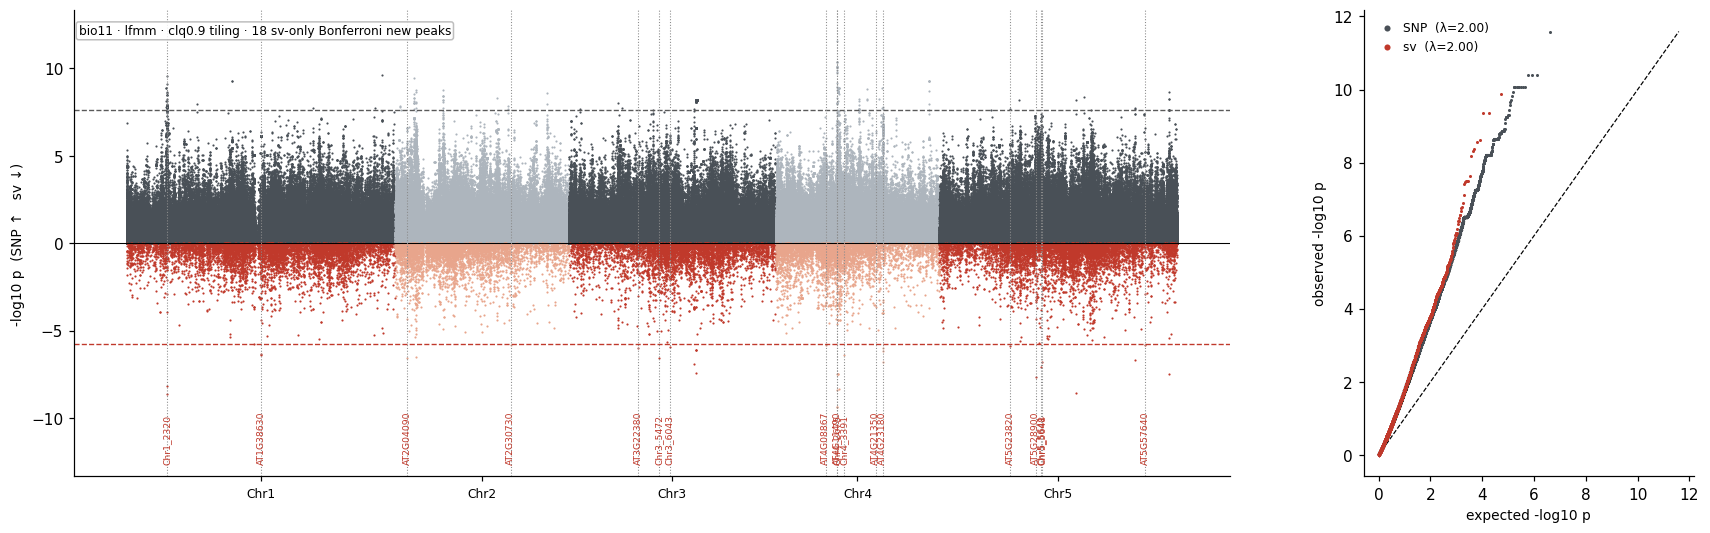

bio11: 18 sv-only Bonferroni new peaks (gene-bearing: 11)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,9.887965,4.123557
2972,Chr4_2720,Chr4,6978538,AT4G11490,9.350834,3.370140
456,Chr1_2320,Chr1,4583448,,8.617121,6.609623
3985,Chr5_5520,Chr5,10926456,AT5G28900;AT5G28910,7.641786,4.327516
2968,Chr4_2675,Chr4,6934090,,7.466529,3.728310
4001,Chr5_5641,Chr5,11481464,,7.103577,3.927402
4003,Chr5_5648,Chr5,11591366,,6.766726,7.281884
2243,Chr3_5472,Chr3,10204785,,6.569275,2.466062
1921,Chr2_825,Chr2,1364859,AT2G04090;AT2G04100,6.562766,6.582677
3056,Chr4_3391,Chr4,7812731,,6.412883,7.012589


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


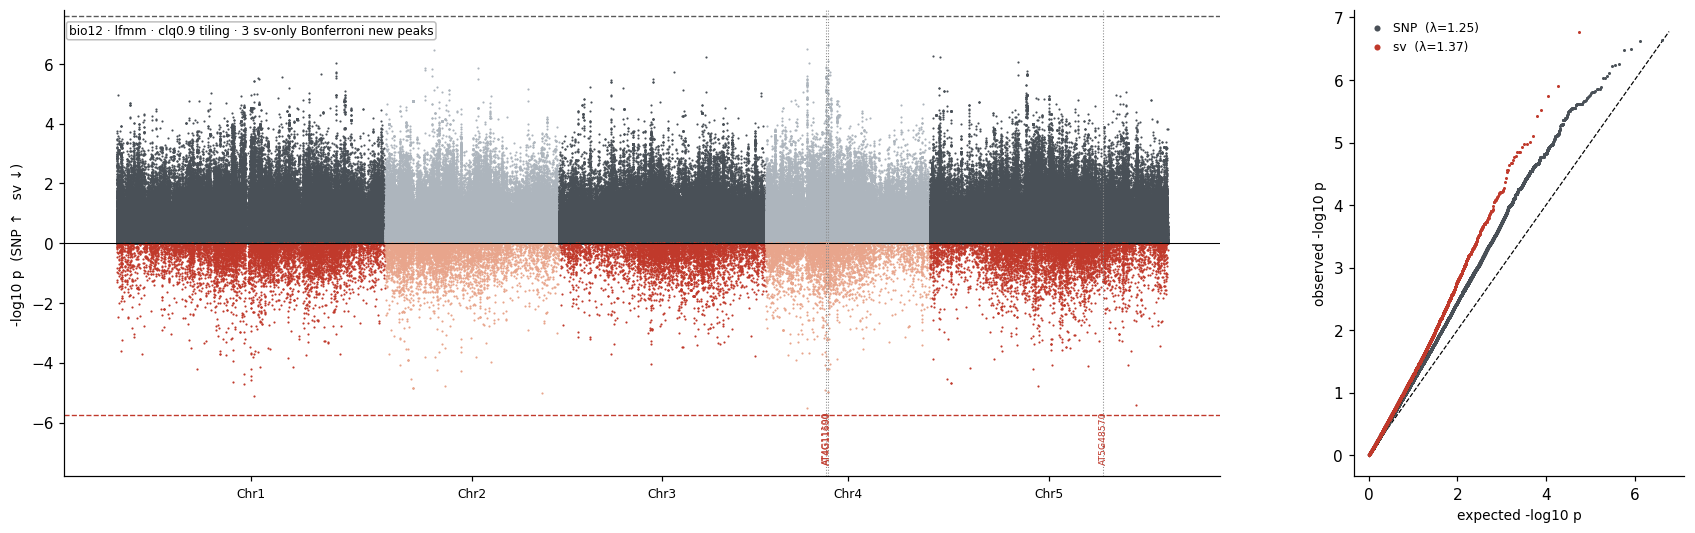

bio12: 3 sv-only Bonferroni new peaks (gene-bearing: 3)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
4512,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,6.775587,2.473560
2951,Chr4_2594,Chr4,6827435,AT4G11190,5.903746,5.883921
2978,Chr4_2749,Chr4,7011705,AT4G11600;AT4G11610,5.742588,6.628982


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


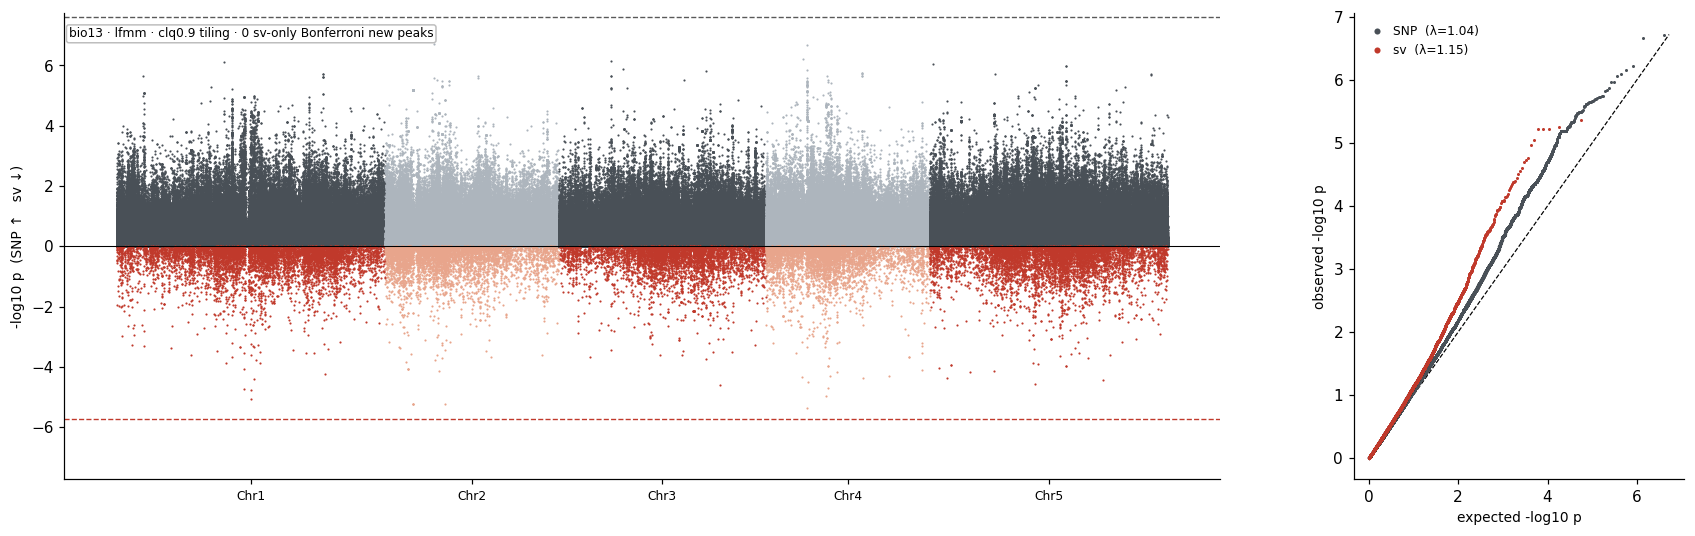

bio13: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


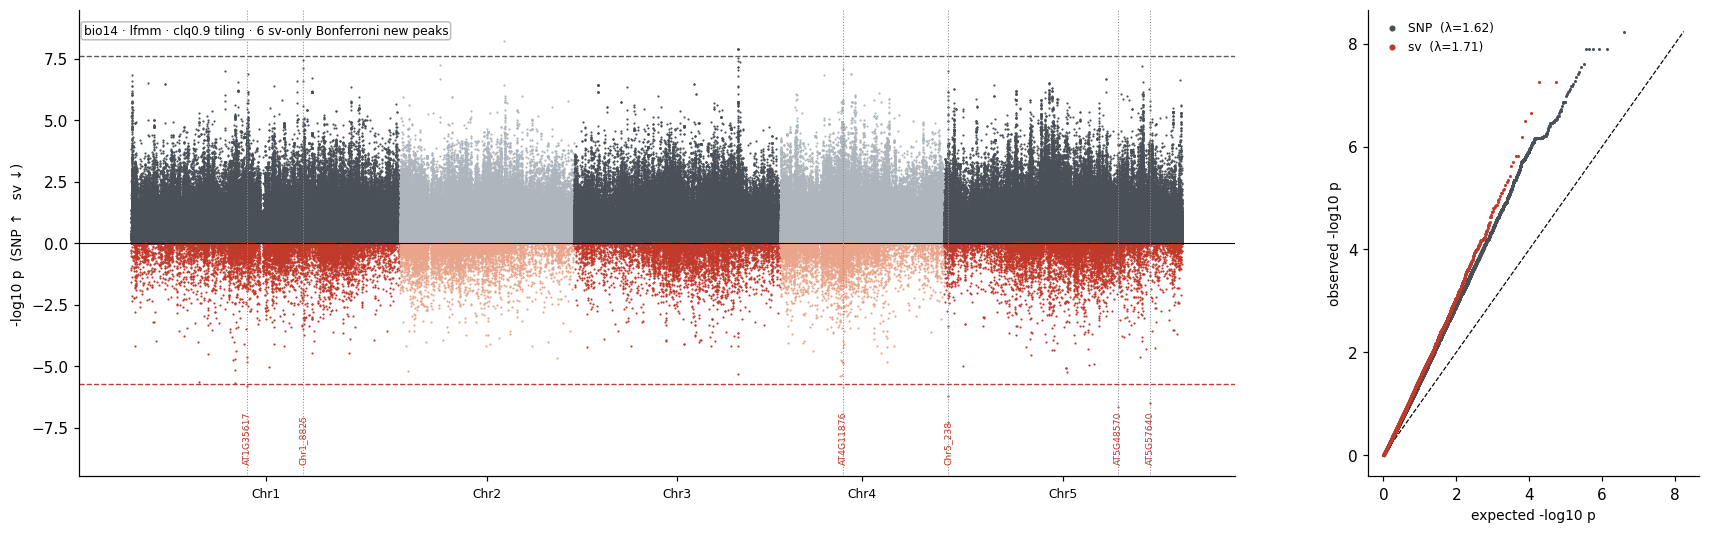

bio14: 6 sv-only Bonferroni new peaks (gene-bearing: 4)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
1082,Chr1_8825,Chr1,19426362,,7.261241,7.441908
3706,Chr5_238,Chr5,394192,,7.250541,7.011941
4512,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,6.657610,2.585836
3567,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,6.502736,5.783475
2994,Chr4_2863,Chr4,7141595,AT4G11876;AT4G11880;AT4G11890,5.824956,4.787165
814,Chr1_6984,Chr1,13154736,AT1G35617,5.818877,4.703077


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


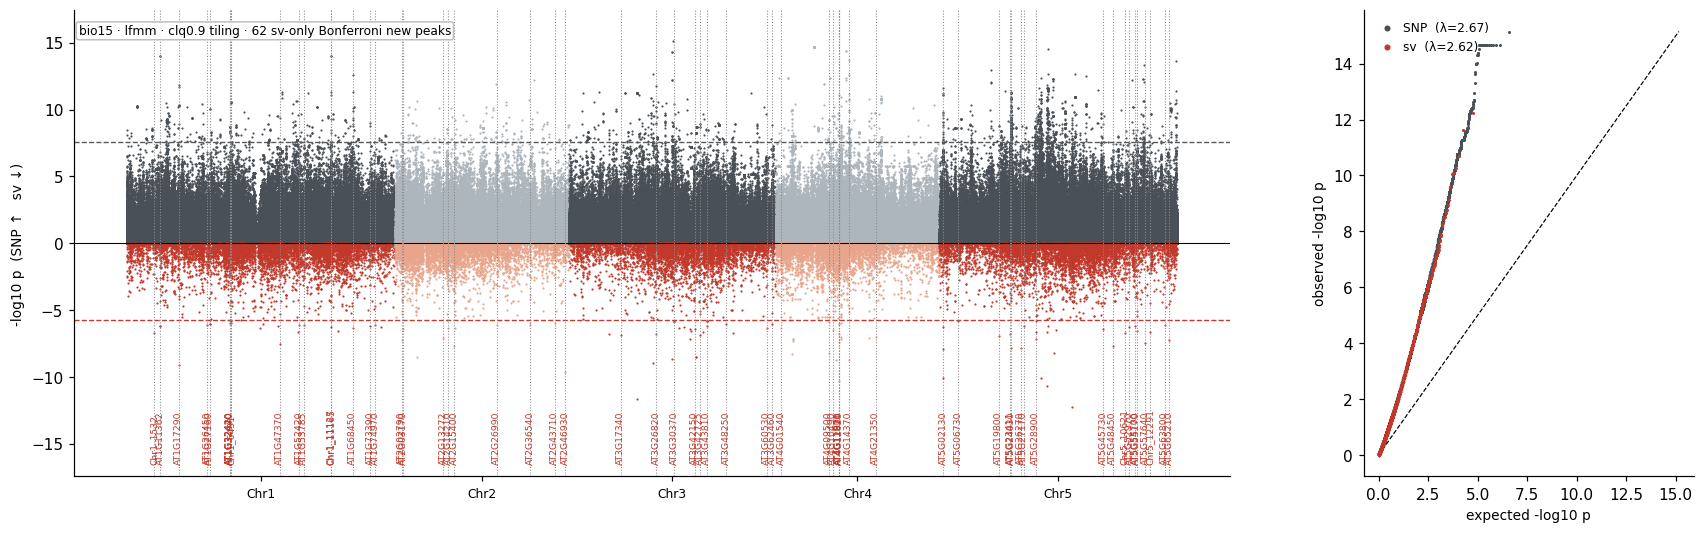

bio15: 62 sv-only Bonferroni new peaks (gene-bearing: 56)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2996,Chr4_2876,Chr4,7167024,AT4G11911;AT4G11920,10.268734,3.584626
1925,Chr2_8310,Chr2,19309838,AT2G46930,9.592534,1.920933
487,Chr1_3031,Chr1,5929272,AT1G17290;AT1G17300,9.105958,3.547864
3087,Chr4_3755,Chr4,8279304,AT4G14370,8.759830,2.592855
3894,Chr5_4928,Chr5,9207553,AT5G26270,7.870615,3.369536
...,...,...,...,...,...,...
3578,Chr5_1232,Chr5,2131980,AT5G06730,5.848333,1.886737
2360,Chr3_6151,Chr3,11965676,AT3G30370,5.825106,6.755999
738,Chr1_6431,Chr1,11819687,,5.797496,6.170920
727,Chr1_6372,Chr1,11709429,AT1G32420;AT1G32430,5.764846,6.841858


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


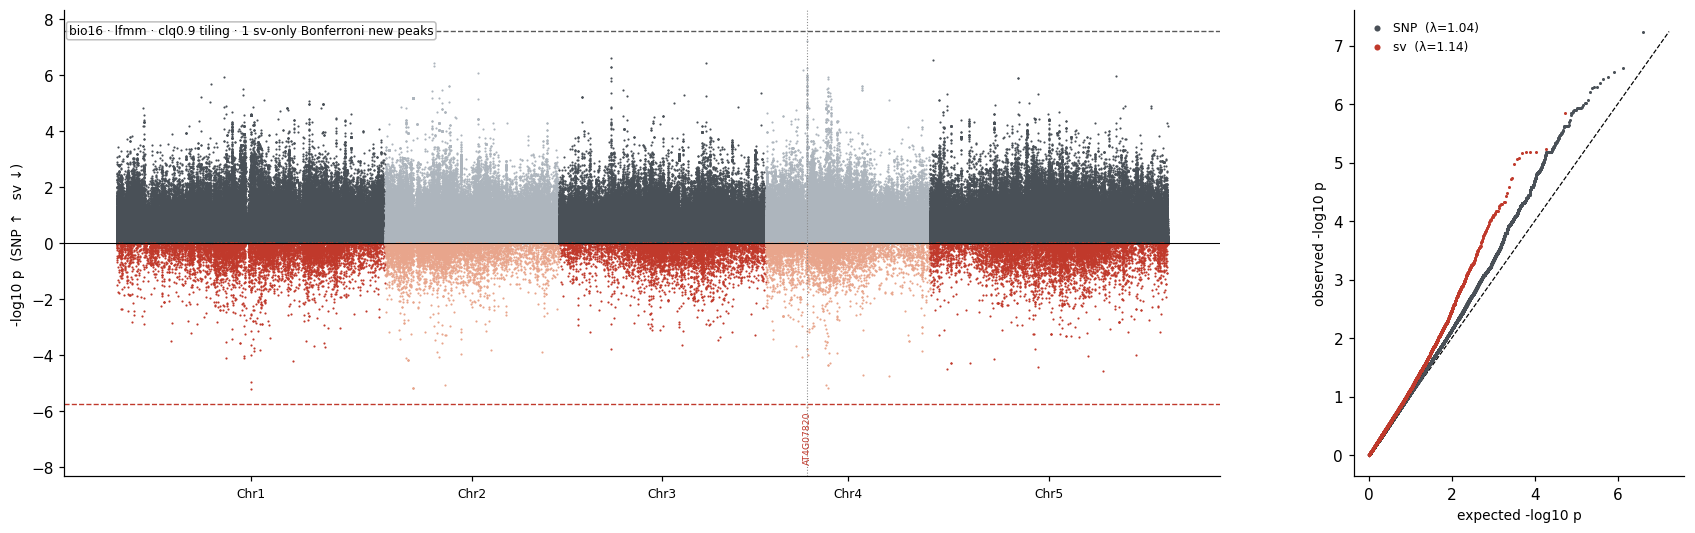

bio16: 1 sv-only Bonferroni new peaks (gene-bearing: 1)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2803,Chr4_1721,Chr4,4700985,AT4G07820;AT4G07825;AT4G07868,5.850414,7.241092


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


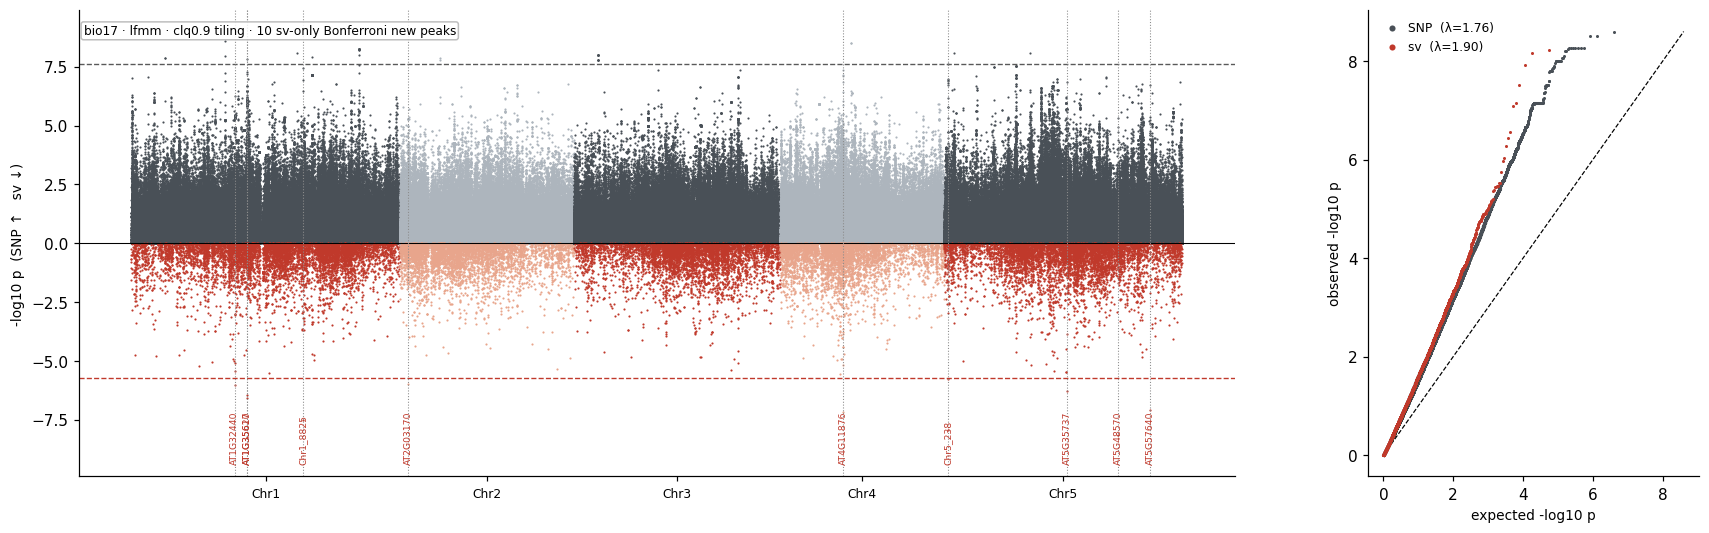

bio17: 10 sv-only Bonferroni new peaks (gene-bearing: 8)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
814,Chr1_6984,Chr1,13154736,AT1G35617,8.235792,6.470815
4512,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,8.160959,2.781528
3706,Chr5_238,Chr5,394192,,7.924947,7.597613
1082,Chr1_8825,Chr1,19426362,,7.511203,7.463486
2994,Chr4_2863,Chr4,7141595,AT4G11876;AT4G11880;AT4G11890,7.160477,6.056338
3567,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,7.085440,6.725121
815,Chr1_6988,Chr1,13155889,AT1G35620,6.553512,4.700805
4081,Chr5_5997,Chr5,13907955,AT5G35737;AT5G35740;AT5G35750;AT5G35753,6.286152,5.693833
728,Chr1_6373,Chr1,11710599,AT1G32440,6.024245,6.238913
1819,Chr2_621,Chr2,965309,AT2G03170;AT2G03180,5.980520,2.542528


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


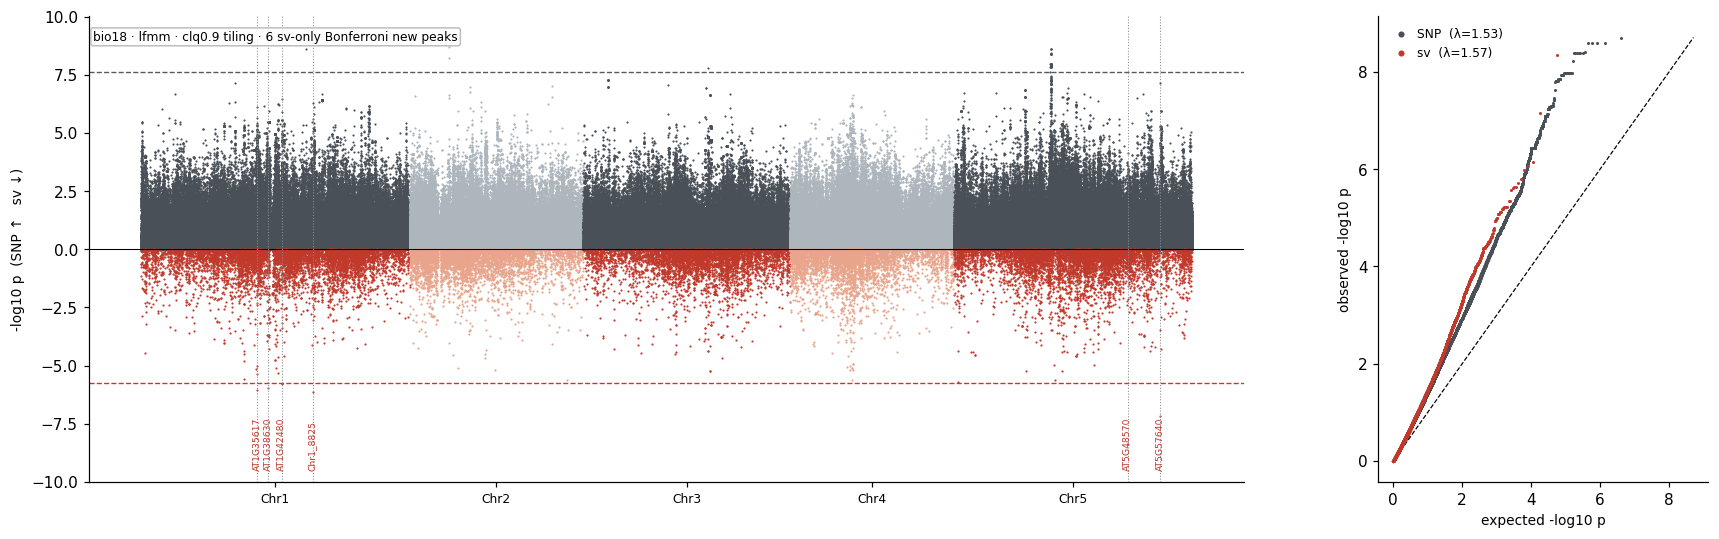

bio18: 6 sv-only Bonferroni new peaks (gene-bearing: 5)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
4512,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,8.349481,2.797133
3567,Chr5_12044,Chr5,23346212,AT5G57640;AT5G57650,7.144627,7.140647
1082,Chr1_8825,Chr1,19426362,,6.138837,6.301530
814,Chr1_6984,Chr1,13154736,AT1G35617,6.061972,5.147115
867,Chr1_7218,Chr1,14432177,AT1G38630;AT1G38790;AT1G38950;AT1G40083;AT1G40...,5.972705,6.245582
878,Chr1_7247,Chr1,15954877,AT1G42480;AT1G42525,5.790816,6.474398


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


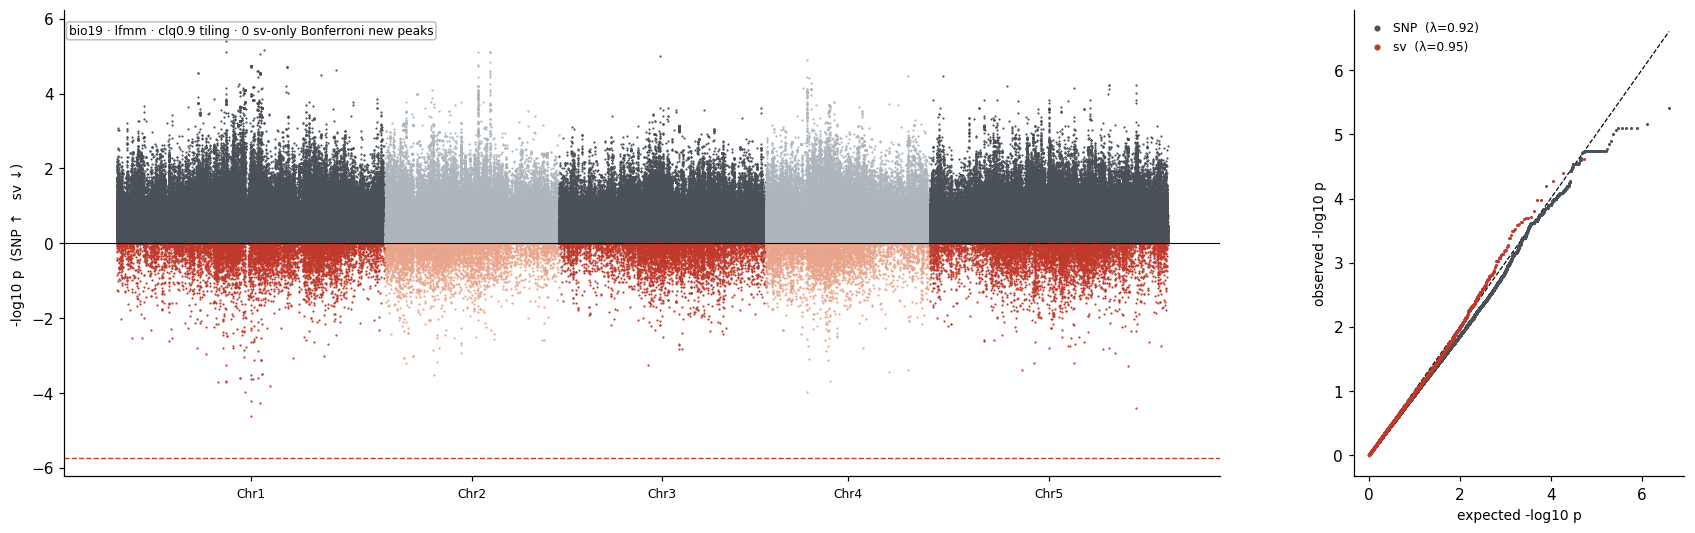

bio19: 0 sv-only Bonferroni new peaks (gene-bearing: 0)


/tmp/ipykernel_1626682/2332778260.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


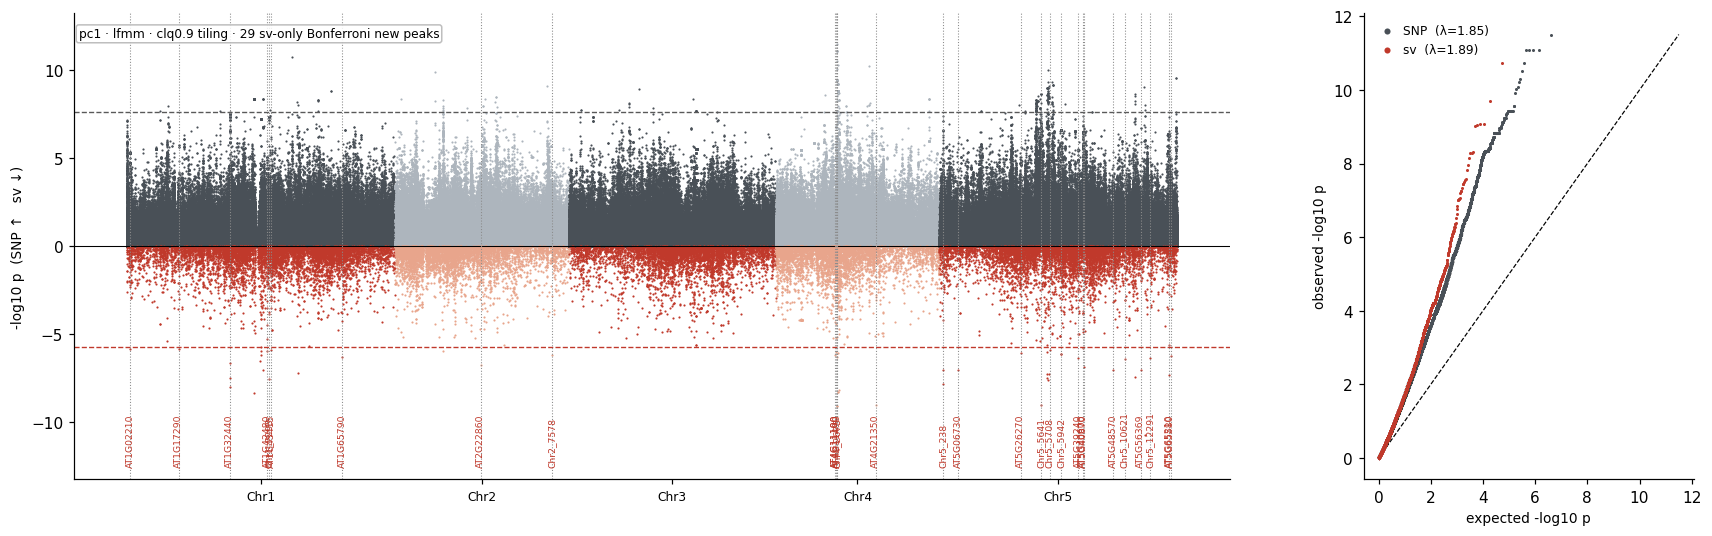

pc1: 29 sv-only Bonferroni new peaks (gene-bearing: 20)


,block,chrom,pos,genes,sv_nlp,snp_nlp_here
2972,Chr4_2720,Chr4,6978538,AT4G11490,9.084179,3.811293
4001,Chr5_5641,Chr5,11481464,,9.040848,4.592110
3245,Chr4_5842,Chr4,11364138,AT4G21350;AT4G21366;AT4G21380,9.007707,2.846045
728,Chr1_6373,Chr1,11710599,AT1G32440,7.970156,6.803148
3706,Chr5_238,Chr5,394192,,7.819288,6.569153
890,Chr1_7293,Chr1,16186470,,7.542989,7.350041
3627,Chr5_13532,Chr5,26073562,AT5G65210;AT5G65220;AT5G65230,7.335057,7.324824
4512,Chr5_9891,Chr5,19695454,AT5G48570;AT5G48575,7.052671,2.202032
3578,Chr5_1232,Chr5,2131980,AT5G06730,7.020792,2.005836
3551,Chr5_11773,Chr5,22840707,AT5G56369;AT5G56370;AT5G56380;AT5G56390,7.008530,6.739161


In [2]:
from scipy import stats

def load_raw(cls, axis):
    f = f"{WZAIN}/{MODEL}_{cls}_gen9_{axis}.csv"
    if not os.path.exists(f): return None
    d = pd.read_csv(f)
    d = d[d["MAF"] > 0.05].copy()
    d["nlp"] = -np.log10(d["pval"].clip(lower=1e-300))
    d["gpos"] = d["chrom"].map(OFF) + d["pos"]
    return d

def leads(d):
    d = d[d["block"].notna() & (d["block"] != "")]
    return d.loc[d.groupby("block")["nlp"].idxmax()]

def gif_lambda(p):
    # genomic inflation factor: median observed chi2(1df) / expected median (0.4549)
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    chi2 = stats.chi2.isf(p, 1)
    return float(np.median(chi2) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=15000, n_bulk=3000):
    # observed vs expected -log10p under the uniform null; thin the dense bulk but
    # keep the whole significant tail (small p). Returns (expected, observed).
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp = -np.log10((np.arange(n) + 0.5) / n)
    obs = -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        head = np.arange(keep_head)                                   # strongest hits, kept in full
        bulk = np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))
        idx = np.concatenate([head, bulk])
    return exp[idx], obs[idx]

def raw_mirror(ax, axis, cls, s, c):
    bonf_s, bonf_c = -np.log10(0.05/len(s)), -np.log10(0.05/len(c))
    ls_, lc_ = leads(s), leads(c)
    m = lc_.merge(ls_[["block", "nlp"]], on="block", suffixes=("", "_snp"), how="left")
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    newpk = m[(m["nlp"] > bonf_c) & (m["nlp_snp"] <= bonf_s)].copy()
    for i, ch in enumerate(CH):
        ss, cc = s[s.chrom == ch], c[c.chrom == ch]
        ax.scatter(ss.gpos, ss.nlp, s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT), rasterized=True, linewidths=0)
        ax.scatter(cc.gpos, -cc.nlp, s=2, c=(CLS_DARK if i % 2 == 0 else CLS_LIGHT), rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bonf_s, ls="--", c="0.35", lw=.9)
    ax.axhline(-bonf_c, ls="--", c=CLS_DARK, lw=.9)
    ymax = max(s.nlp.max(), c.nlp.max()) * 1.15
    newpk["genes"] = newpk["block"].map(lambda b: ";".join(genes_on(b)))
    for _, r in newpk.iterrows():
        lab = r.genes.split(";")[0] if r.genes else r.block
        ax.axvline(r.gpos, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(r.gpos, -ymax*0.95), ha="center", va="bottom", fontsize=6,
                    color=CLS_DARK, rotation=90)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c]+CHROM_LEN[c]/2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {cls} \u2193)", fontsize=9)
    ax.annotate(f"{axis} \u00b7 lfmm \u00b7 clq0.9 tiling \u00b7 {len(newpk)} {cls}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return newpk[["block", "chrom", "pos", "nlp", "nlp_snp", "genes"]].sort_values("nlp", ascending=False)

def qq_panel(ax, cls, s, c):
    lam_s, lam_c = gif_lambda(s["pval"]), gif_lambda(c["pval"])
    xs, ys = qq_xy(s["pval"].to_numpy()); xc, yc = qq_xy(c["pval"].to_numpy())
    hi = max(xs.max(), ys.max(), xc.max(), yc.max())
    ax.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)                 # null diagonal
    ax.scatter(xs, ys, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"SNP  (\u03bb={lam_s:.2f})")
    ax.scatter(xc, yc, s=4, c=CLS_DARK, rasterized=True, linewidths=0, zorder=2,
               label=f"{cls}  (\u03bb={lam_c:.2f})")
    ax.set_xlabel("expected -log10 p", fontsize=9)
    ax.set_ylabel("observed -log10 p", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    return lam_s, lam_c

all_newpk = []
for axis in AXES:
    s, c = load_raw("snp", axis), load_raw(CLS, axis)
    if s is None or c is None:
        print(f"missing {axis}"); continue
    fig = plt.figure(figsize=(19, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.18)
    newpk = raw_mirror(fig.add_subplot(gs[0]), axis, CLS, s, c)
    qq_panel(fig.add_subplot(gs[1]), CLS, s, c)
    fig.tight_layout(); plt.show()
    newpk = newpk.copy(); newpk["axis"] = axis
    all_newpk.append(newpk)
    print(f"{axis}: {len(newpk)} {CLS}-only Bonferroni new peaks (gene-bearing: {(newpk.genes != '').sum()})")
    if len(newpk):
        display(newpk[["block", "chrom", "pos", "genes", "nlp", "nlp_snp"]].rename(
            columns={"nlp": f"{CLS}_nlp", "nlp_snp": "snp_nlp_here"}))

## Candidate genes — SV-only new peaks, consolidated across all 20 axes

Union of every gene-bearing new peak found above, deduplicated per gene (kept: the
axis with the strongest sv signal), with Ensembl Plants symbol/description and a
recurrence count (how many of the 20 axes flag that gene's block). **Raw, uncalibrated
p — no GIF correction here** (see the `gif_manhattan_snp_vs_sv_lfmm_tile.ipynb` twin
for the inflation-corrected version; the session finding there is that this raw list
collapses almost entirely once genomic inflation is accounted for).

In [3]:
import json, time, urllib.request

ALL = pd.concat(all_newpk, ignore_index=True) if all_newpk else pd.DataFrame(columns=["block","gene","axis","nlp"])
gene_rows = []
for _, r in ALL.iterrows():
    for g in (r.genes.split(";") if r.genes else []):
        gene_rows.append(dict(gene=g, block=r.block, chrom=r.chrom, pos=r.pos, axis=r.axis, nlp=r.nlp))
G = pd.DataFrame(gene_rows)
if len(G):
    recur = G.groupby("gene")["axis"].nunique().rename("n_axes")
    best = G.sort_values("nlp", ascending=False).drop_duplicates("gene").set_index("gene")
    cand = best.join(recur).sort_values("n_axes", ascending=False).reset_index()

    def ensembl_symbols(ids, chunk=900, retries=3):
        out = {}
        for i in range(0, len(ids), chunk):
            sub = ids[i:i + chunk]
            req = urllib.request.Request("https://rest.ensembl.org/lookup/id",
                data=json.dumps({"ids": sub}).encode(),
                headers={"Content-Type": "application/json", "Accept": "application/json"})
            for attempt in range(retries):
                try:
                    with urllib.request.urlopen(req, timeout=60) as r:
                        d = json.load(r)
                    for k, v in d.items():
                        if v:
                            out[k] = (v.get("display_name", "") or "", (v.get("description", "") or "").split(" [Source")[0])
                    break
                except Exception as e:
                    print(f"  [ensembl] chunk {i} attempt {attempt+1}: {e}", flush=True); time.sleep(2)
        return out

    sym = ensembl_symbols(sorted(cand.gene.unique()))
    cand["symbol"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[0])
    cand["description"] = cand.gene.map(lambda x: sym.get(x, ("", ""))[1])
    cand.to_csv(f"{lib.GEA}/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_tile.csv", index=False)
    print(f"{len(cand)} unique {CLS}-only new-peak genes across 20 axes")
    display(cand[["gene", "symbol", "description", "block", "chrom", "pos", "n_axes", "nlp"]].head(50))
else:
    print("no gene-bearing new peaks found on any axis")

347 unique sv-only new-peak genes across 20 axes


,gene,symbol,description,block,chrom,pos,n_axes,nlp
0,AT5G57640,AT5G57640,GCK domain-containing protein,Chr5_12044,Chr5,23346212,8,7.443996
1,AT4G21380,RK3,receptor kinase 3,Chr4_5842,Chr4,11364138,8,9.887965
2,AT5G57650,AT5G57650,eukaryotic translation initiation factor-like ...,Chr5_12044,Chr5,23346212,8,7.443996
3,AT4G21350,PUB8,plant U-box 8,Chr4_5842,Chr4,11364138,8,9.887965
4,AT4G21366,AT4G21366,Protein kinase superfamily protein,Chr4_5842,Chr4,11364138,8,9.887965
5,AT4G11490,CRK33,cysteine-rich RLK (RECEPTOR-like protein kinas...,Chr4_2720,Chr4,6978538,6,10.377719
6,AT1G42480,AT1G42480,TLR4 regulator/MIR-interacting MSAP protein,Chr1_7247,Chr1,15961035,5,6.766079
7,AT1G42525,AT1G42525,cysteine proteinase superfamily protein,Chr1_7247,Chr1,15961035,5,6.766079
8,AT5G48570,AT5G48570,FKBP-type peptidyl-prolyl cis-trans isomerase ...,Chr5_9891,Chr5,19695454,5,8.349481
9,AT5G48575,AT5G48575,mediator of RNA polymerase II transcription su...,Chr5_9891,Chr5,19695454,5,8.349481


## Functional theme per gene — stress / climate / flowering / circadian / defense

Same SV-only new-peak gene list, now tagged with a **functional category** via
the project annotator `annotate_genes_tair_uniprot.py` (TAIR GO + UniProt — the mandated
route, *not* ad-hoc Ensembl/mygene). Categories, with the axis each targets:
`flowering` (flowering time, vernalization, photoperiod, **circadian**, meristem identity) ·
`temperature` (cold/freezing/heat, CBF/DREB/COR) · `water` (drought, osmotic, ABA, salinity,
stomata) · `light` (photomorphogenesis, UV, shade avoidance, photosynthesis) · `oxidative`
(ROS, abiotic/general stress response) · `defense` (immunity, pathogen, SA/JA, R-genes) ·
`calcium` (Ca2+/calmodulin/CDPK signalling). A gene can carry several. `categories` empty =
none of the above matched its curated protein name + UniProt FUNCTION/keywords + GO.
Written to `raw_manhattan_newpeak_genes_sv_tile_annotated.csv`. **Raw, uncalibrated p** —
see the GIF twin for the inflation-corrected view.

In [4]:
import importlib.util as _ilu

_annp = os.path.abspath(os.path.join(os.getcwd(), "..", "annotate_genes_tair_uniprot.py"))
_sp = _ilu.spec_from_file_location("ann_tu", _annp)
ann_tu = _ilu.module_from_spec(_sp); _sp.loader.exec_module(ann_tu)

if "cand" in dir() and len(cand):
    _A = ann_tu.annotate(sorted(cand["gene"].unique()))
    _cols = ["gene", "protein_name", "categories", "climate_stress_flowering",
             "uniprot_function", "uniprot_keywords"]
    cand_annot = cand.merge(_A[_cols], on="gene", how="left")
    cand_annot["categories"] = cand_annot["categories"].fillna("")
    _outp = f"{lib.GEA}/phase1_replication/results/multiaxis/raw_manhattan_newpeak_genes_{CLS}_tile_annotated.csv"
    cand_annot.to_csv(_outp, index=False)
    _ntag = int((cand_annot["categories"].str.len() > 0).sum())
    print(f"{len(cand_annot)} genes annotated ; {_ntag} tagged to >=1 climate/stress/flowering/defense category")
    print("\ncategory counts (a gene can carry several):")
    print(cand_annot["categories"].str.split(",").explode().replace("", pd.NA)
          .dropna().value_counts().to_string())
    display(cand_annot[["gene", "symbol", "protein_name", "categories", "n_axes",
                        "nlp", "chrom", "pos"]].sort_values(["n_axes", "nlp"],
                        ascending=False).head(60))
else:
    cand_annot = pd.DataFrame(columns=["gene", "symbol", "categories"])
    print("no genes to annotate")

annotating 347 genes

-- TAIR GAF (GO Consortium) --


GAF cache: /global/scratch/projects/fc_moilab/tbellg/kmate/analysis/grenenet_gea/phase1_replication/results/cache/tair.gaf.gz (7.2 MB)


   GO for 253/347 genes
-- UniProt REST pass 1: reviewed / Swiss-Prot (taxid 3702) --


  uniprot 40/347 -> 15 mapped


  uniprot 80/347 -> 38 mapped


...

  uniprot 160/180 -> 147 mapped


  uniprot 180/180 -> 167 mapped


   UniProt total: 334/347 genes
-- mygene.info (kept for GO term NAMES + entrez) --


347 genes annotated ; 98 tagged to >=1 climate/stress/flowering/defense category

category counts (a gene can carry several):
categories
defense        58
temperature    23
water          18
oxidative      17
calcium        12
flowering       8
light           7


,gene,symbol,protein_name,categories,n_axes,nlp,chrom,pos
1,AT4G21380,RK3,Receptor-like serine/threonine-protein kinase ...,defense,8,9.887965,Chr4,11364138
3,AT4G21350,PUB8,U-box domain-containing protein 8 (EC 2.3.2.27...,water,8,9.887965,Chr4,11364138
4,AT4G21366,AT4G21366,Protein kinase superfamily protein,,8,9.887965,Chr4,11364138
0,AT5G57640,AT5G57640,GCK domain-containing protein,,8,7.443996,Chr5,23346212
2,AT5G57650,AT5G57650,Eukaryotic translation initiation factor-like ...,,8,7.443996,Chr5,23346212
5,AT4G11490,CRK33,Putative cysteine-rich receptor-like protein k...,defense,6,10.377719,Chr4,6978538
8,AT5G48570,AT5G48570,Peptidyl-prolyl cis-trans isomerase FKBP65 (PP...,"temperature,defense,calcium",5,8.349481,Chr5,19695454
9,AT5G48575,AT5G48575,DUF1216 domain-containing protein,,5,8.349481,Chr5,19695454
6,AT1G42480,AT1G42480,TLR4 regulator/MIR-interacting MSAP protein,,5,6.766079,Chr1,15961035
7,AT1G42525,AT1G42525,Cysteine proteinase superfamily protein,,5,6.766079,Chr1,15961035


## Dot plot — recurrent SV-only new-peak genes across the 20 climate axes

One dot per (gene, axis) where that gene's block is an sv-only Bonferroni new peak on
that axis. **Dot size** = -log10 p (that axis' sv lead); **color** = functional category
(above). Genes are ordered genomically (chrom then position) and the panel is limited to
genes recurring on **enough axes to stay legible** (auto-threshold, printed below); the
full 347-gene list with categories is the table above. Reading across a row shows how many
of the 20 climate variables independently flag that gene's block.

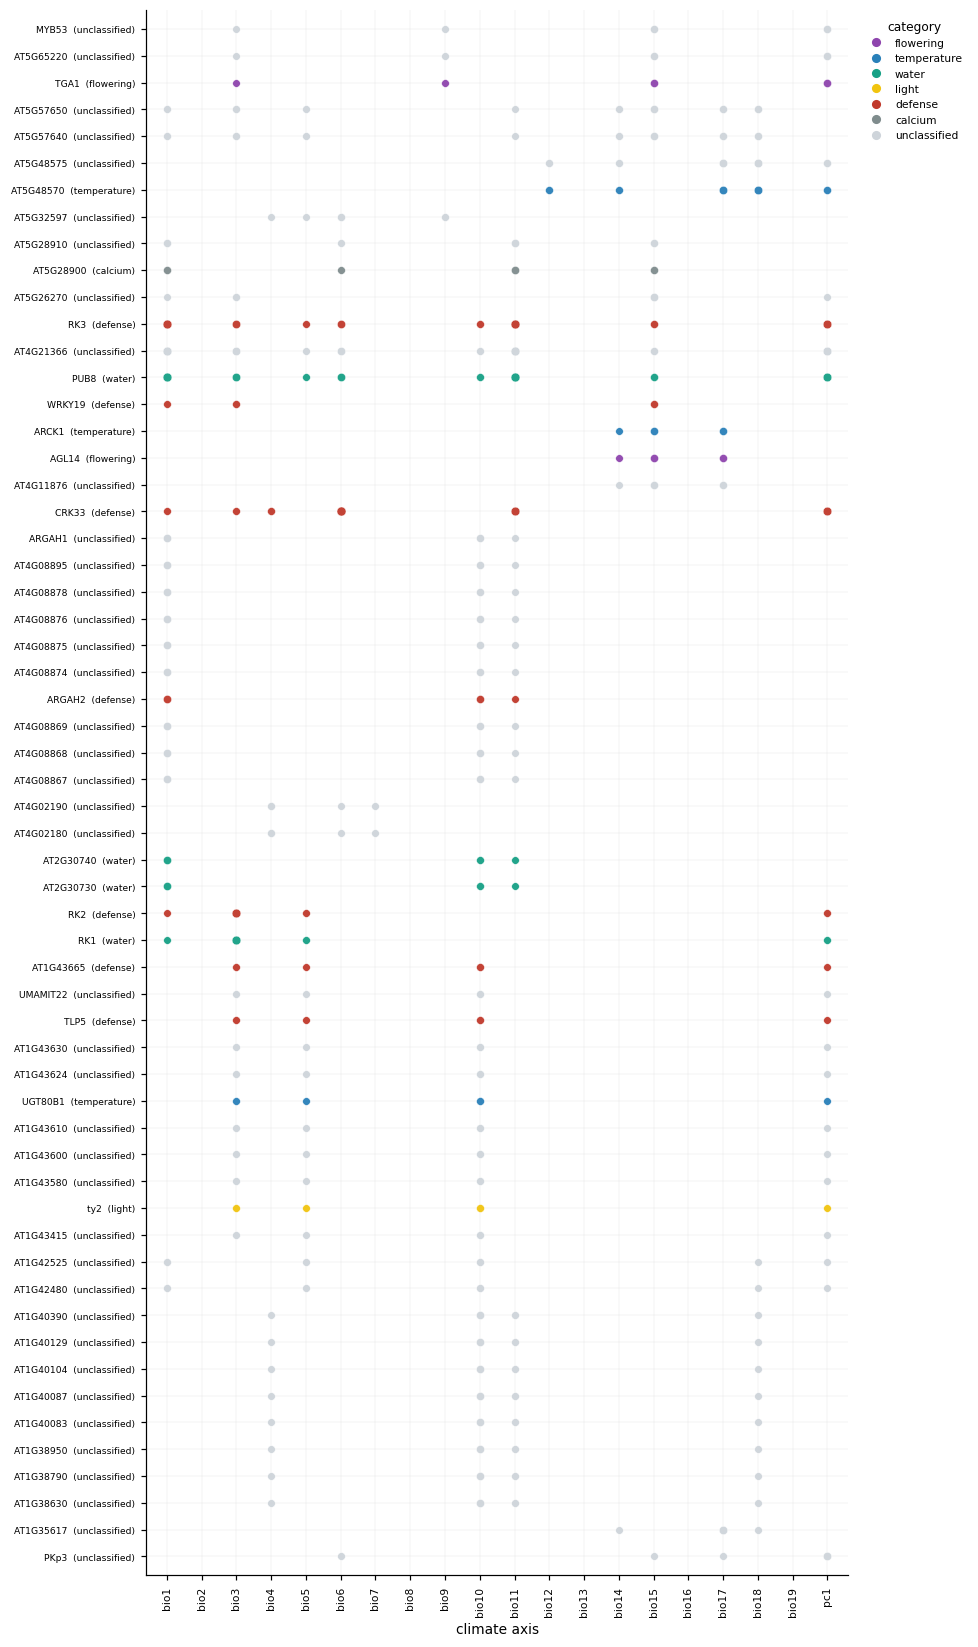

dot plot: 58 genes recurring on >=3 of 20 axes (auto-threshold for legibility); 289 of 347 lower-recurrence genes omitted from the plot but present in the annotated table/CSV.


In [5]:
import matplotlib.lines as mlines

AXES_ORD = [f"bio{i}" for i in range(1, 20)] + ["pc1"]
_rows = []
if all_newpk:
    for r in pd.concat(all_newpk, ignore_index=True).itertuples():
        for g in (r.genes.split(";") if r.genes else []):
            _rows.append(dict(gene=g, axis=r.axis, nlp=r.nlp, chrom=r.chrom, pos=r.pos))
GX = pd.DataFrame(_rows)

if len(GX):
    _nax = GX.groupby("gene")["axis"].nunique()
    thr = 2
    while int((_nax >= thr).sum()) > 70 and thr < 8:
        thr += 1
    keep_genes = set(_nax[_nax >= thr].index)
    D = GX[GX["gene"].isin(keep_genes)].drop_duplicates(["gene", "axis"]).copy()
    gord = (D.drop_duplicates("gene")
            .assign(_cn=lambda x: x["chrom"].str.replace("Chr", "", regex=False).astype(int))
            .sort_values(["_cn", "pos"])["gene"].tolist())
    catmap = dict(zip(cand_annot["gene"], cand_annot["categories"])) if len(cand_annot) else {}
    symmap = dict(zip(cand_annot["gene"], cand_annot["symbol"])) if len(cand_annot) else {}
    def _pcat(g):
        c = [x for x in (catmap.get(g, "") or "").split(",") if x]
        return c[0] if c else "unclassified"
    CATCOL = {"flowering": "#8E44AD", "temperature": "#2980B9", "water": "#16A085",
              "light": "#F1C40F", "oxidative": "#E67E22", "defense": "#C0392B",
              "calcium": "#7F8C8D", "unclassified": "#CED4DA"}
    yidx = {g: i for i, g in enumerate(gord)}
    xidx = {a: i for i, a in enumerate(AXES_ORD)}
    fig, ax = plt.subplots(figsize=(9, max(4, 0.26 * len(gord))))
    for _, rr in D.iterrows():
        ax.scatter(xidx[rr["axis"]], yidx[rr["gene"]], s=12 + rr["nlp"] * 2.2,
                   c=CATCOL.get(_pcat(rr["gene"]), "#CED4DA"), edgecolors="white",
                   linewidths=0.3, alpha=0.95, zorder=3)
    ax.set_xticks(range(len(AXES_ORD))); ax.set_xticklabels(AXES_ORD, rotation=90, fontsize=7)
    ax.set_yticks(range(len(gord)))
    ax.set_yticklabels([f"{(symmap.get(g) or g)}  ({_pcat(g)})" for g in gord], fontsize=6)
    ax.set_xlim(-0.6, len(AXES_ORD) - 0.4); ax.set_ylim(-0.7, len(gord) - 0.3)
    ax.grid(True, axis="both", lw=0.3, c="0.9", zorder=0); ax.set_axisbelow(True)
    ax.set_xlabel("climate axis", fontsize=9)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    _present = [c for c in CATCOL if c in {_pcat(g) for g in gord}]
    _h = [mlines.Line2D([], [], marker="o", ls="", ms=7, mfc=CATCOL[c], mec="white", label=c)
          for c in _present]
    ax.legend(handles=_h, title="category", loc="upper left", bbox_to_anchor=(1.01, 1.0),
              frameon=False, fontsize=7, title_fontsize=8)
    fig.tight_layout(); plt.show()
    _tot = GX["gene"].nunique()
    print(f"dot plot: {len(gord)} genes recurring on >={thr} of 20 axes "
          f"(auto-threshold for legibility); {_tot - len(gord)} of {_tot} lower-recurrence "
          f"genes omitted from the plot but present in the annotated table/CSV.")
else:
    print("no gene-bearing new peaks to plot")